# Assignment 3

***


SetUp

In [1]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import plotly.express as px


import requests

'''
Data dictionary :  https://files.ontario.ca/fuelsdatadictionary_0.xlsx

'''

# Import dataset from csv file to a dataframe
df = pd.read_csv("https://ontario.ca/v1/files/fuel-prices/fueltypesall.csv")

# Changing data type for date for easier manipulation.
df['Date'] = pd.to_datetime(df['Date'])


''' 
Creation of subset for visualizations with specific columns:
 * Date
 * Ontario Average
 * Fuel Type
 * Data from 1990 - prev year.

'''

# Date filters.
# Excluding current year to show only complete years.
current_year = datetime.now().year
past_10_year = (datetime.now().year-1)-10


df_viz = df.iloc[:, [0,15,18]].copy()
df_viz = df_viz[df_viz['Date'].dt.year < current_year]

# Renaming of columns
df_viz = df_viz.rename(columns={"Ontario Average/Moyenne provinciale": "Ontario Price"})



***

## Visualization #1

In [3]:
''' 
For Visualization #1
Goal: Represent the average price of all types of fuels across time in Ontario.
 
'''

# Calculate Avg per year and per fuel type.
yearly_avg = df_viz.groupby([df_viz['Date'].dt.year, df_viz['Fuel Type']])['Ontario Price'].mean().reset_index()

# Handling NaN for Compressed Natural Gas for 2018
naturalgas_avg = yearly_avg[yearly_avg['Fuel Type'] == 'Compressed Natural Gas']['Ontario Price'].mean()

missing_value = {'Date': 2018, 'Fuel Type': 'Compressed Natural Gas', 'Ontario Price': f"{naturalgas_avg:.4f}"}

#Adding the average for Compressed Natural Gas to the Dataframe.
yearly_avg.loc[len(yearly_avg)] = missing_value


#Creating Pivot table by Fuel Type for visualization
yearly_avg = yearly_avg.pivot(index='Date', columns='Fuel Type', values='Ontario Price')


yearly_avg

Fuel Type,Auto Propane,Compressed Natural Gas,Diesel,Mid-Grade Gasoline,Premium Gasoline,Regular Unleaded Gasoline
Date,,,,,,
1990,24.417308,33.315385,49.794231,58.826923,60.832692,56.169231
1991,35.855769,46.859615,52.605769,57.892308,60.35,54.759615
1992,30.883019,49.222642,51.284906,57.49434,60.573585,53.841509
1993,30.848077,49.426923,50.925,56.428846,60.078846,52.511538
1994,29.369231,50.361538,49.942308,55.738462,59.573077,51.355769
1995,29.401923,52.094231,48.844231,59.078846,62.903846,54.026923
1996,33.056604,52.583019,52.673585,62.515094,66.469811,57.101887
1997,31.405769,55.459615,53.396154,62.721154,67.340385,57.211538
1998,28.348077,57.007692,49.5,57.748077,62.580769,52.075


In [27]:
#Comparing specific levels to eachother.

fig = px.area(yearly_avg, 
              facet_col="Fuel Type", 
              facet_col_wrap=3, 
              labels={"Date": "", "value":"Cents per Litre ($)"},
              height=1200, 
              width=2000,
              facet_row_spacing=0.1, # default is 0.07 when facet_col_wrap is used
              facet_col_spacing=0.05
              )


# Customizing style for title
fig.update_layout(
    title=dict(
        text= "Average Price per Litre for Fuels in Ontario since 1990",
        xanchor = 'center',
        yanchor = 'top' ,  
        y = 0.99,
        x = 0.5),
        margin=dict( t=100    ) ,
        title_font_family="Arial Black",
        title_font_size = 25,
        title_font_color = 'black',
        font_size = 16,
        showlegend=False
        )

# Customizing hover textbox
fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        font_size=14,
        font_family="Arial"
    )
)
fig.update_traces(mode="markers+lines")


# Adding annotation for Covid on 2020
fig.add_vrect(x0="2020", x1="2021", 
              annotation_text="COVID", annotation_position="top right", 
              fillcolor="black", opacity=0.25, line_width=0)

#Customizing Subtitles and Axis
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1], font_size = 19, font_family="Arial Black"))
fig.for_each_yaxis(lambda y: y.update(showticklabels=True))
fig.for_each_xaxis(lambda x: x.update(showticklabels=True, tickangle=35))



#Annotation
note =  f"""
Prices displayed in CAD cents. 
Period observed: 1990 - {current_year-1}
Developer: Nuria Sanchez  sanchez.nuria@gmail.com  Data Source: Ontario's Open Data Catalogue. https://ontario.ca/v1/files/fuel-prices/fueltypesall.csv
"""

 
fig.add_annotation(
    text=note,
    xref="x domain", yref="y domain",
    x=0.01, y=-0.17, # x=0.5 centra el texto, y negativo lo pone debajo
    showarrow=False,
    font=dict(size=14, color="black")
)


fig.show()

#Due to limitations with Ploty, the PNG must be saved manually.

## Average Price per Litre for Fuels in Ontario, since 1990.

The visualization represents the average price for fuels in Ontario from 1990 to the most recently completed year. Prices are represented in cents per litre. The fuels considered are:
* Auto Propane
* Compressed Natural Gas
* Diesel
* Mid-Grade Gasoline
* Premiumn Gasoline
* Regular Unleaded Gasoline

---
I created my data visualization using Python, leveraging the Plotly library to generate an area-style relational plot. Plotly was intentionally selected because it produces dynamic and interactive graphs, which significantly enhance the user’s ability to read and interpret data. Unlike static charts, a Plotly visualization allows users to hover over data points to see precise values, zoom into specific time periods, and interact with the timeline. This interactivity reduces visual overload and makes it easier for the final user to explore the data at their own pace.

The intended audience includes policymakers, researchers, students, business professionals in the energy and transportation sectors, and residents of Ontario who are interested in understanding long-term fuel price trends. Because fuel prices directly affect household budgets, transportation planning, and economic policy, the visualization was designed to be accessible to both technical and non-technical audiences.

The primary message of the visualization is to show how fuel prices in Ontario have evolved over time, highlighting long-term trends, fluctuations, and potential periods of volatility. By presenting the data in a continuous area graph, viewers can easily observe patterns such as gradual increases, sharp spikes, or periods of relative stability. The goal is not only to present raw data, but to make historical price evolution immediately interpretable. A vertical reference line was added to mark the COVID-19 period in 2020, providing important contextual information and helping viewers clearly see how the pandemic corresponded with unusual price movements during that year.

Several design principles guided the creation of the visualization. First, clarity and readability were central considerations. I used a font size of 20 for the main title, 19 for subtitles, and 14 for notes to create a clear visual hierarchy. This ensures that viewers can quickly identify the purpose of the graph and interpret contextual information without straining to read small text. I also forced axis labels to repeat on each graph panel to improve comprehension, especially if multiple facets are displayed. This prevents viewers from having to search for contextual clues elsewhere on the figure.

Reproducibility was ensured by generating the visualization entirely through Python code. Anyone with access to the dataset and script can recreate the same interactive figure. The script includes dynamic time detection, such as automatically identifying the most recent completed year rather than hardcoding a fixed end date. This ensures that when new data is added, the visualization updates automatically without manual adjustments. Because Plotly graphs are generated programmatically, transparency and credibility are strengthened. If a non-reproducible tool had been used, updates would be less efficient and trust in the results could be reduced.

Accessibility was considered beyond color usage. Clear font sizing improves readability for individuals with mild visual impairments, and consistent labeling ensures the graph can be interpreted without ambiguity. The interactive hover function also supports accessibility by allowing users to retrieve precise values without straining to read small labels. The structured layout and reduced clutter help minimize cognitive overload.

The individuals and communities impacted by this visualization include Ontario residents, particularly drivers and households affected by fuel price fluctuations. Policymakers and economists may use the visualization to evaluate inflation trends or assess energy-related policies. Businesses in logistics and transportation may rely on this information for forecasting and budgeting, while researchers studying energy economics or environmental policy may benefit from the long-term historical perspective.

When selecting features from the dataset, I focused on variables directly aligned with the central message: year and average fuel price in Ontario. Additional variables were excluded to maintain clarity and prevent visual clutter. The time range was intentionally set from 1990 to the most recently completed year to provide sufficient historical context while keeping the visualization focused and readable.

Finally, significant “underwater labour” contributed to the final product. This included cleaning and validating the dataset, ensuring consistent formatting across years, verifying correct average calculations, and checking for missing or anomalous values. Additional work involved refining layout, adjusting grid visibility, testing font scaling, and confirming that the interactive features functioned properly across different screen sizes. Although this work is not directly visible in the final graph, it was essential to producing a clear, dynamic, accessible, and reliable data visualization.

___

## Visualization #2


In [ ]:
'''
For Visualization #2
Goal: Represent the average of Regular gas in Ontario in a scope of 10 calendar years (excludes current year).
Period : 2015 2025
Fuel Type : Regular Unleaded Gasoline 
Agregations : Average per year and month.

'''


ontario_10y = df_viz[df_viz['Date'].dt.year >= past_10_year].copy()

#Creating columns of year and month for heatmap
ontario_10y['year'] = ontario_10y['Date'].dt.year
ontario_10y['month'] = ontario_10y['Date'].dt.month_name().str[:3]


#Filtering only Regular Gasoline
ontario_10y = ontario_10y[ontario_10y['Fuel Type'] == 'Regular Unleaded Gasoline']


# Calculate Avg per year and per month and year in Ontario for Regular Gasoline
ontario_10y = ontario_10y.groupby([ontario_10y['year'], ontario_10y['month']]).agg(
                AvgPrice = ('Ontario Price', 'mean'),
                MaxPrice = ('Ontario Price', 'max'),
                MinPrice = ('Ontario Price', 'min')
).reset_index()


# Create months order for heatmap
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert 'Month' to Categorical type to enforce order
ontario_10y['month'] = pd.Categorical(ontario_10y['month'], categories=month_order, ordered=True)

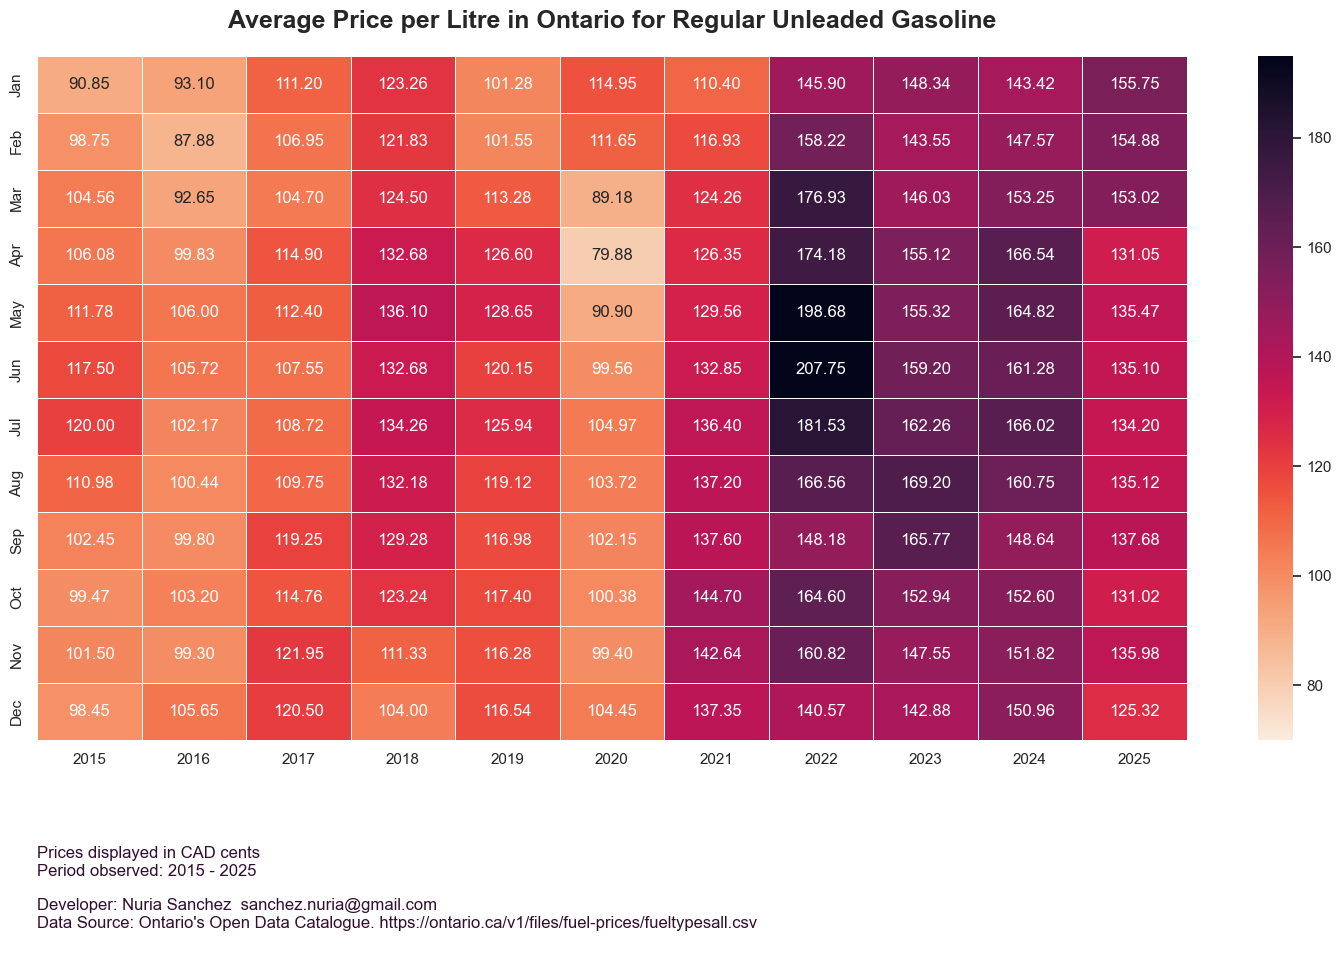

In [ ]:
'''
Creation on HeatMap
Style :
Y axis : Months
X axis : Years
Values : Average Price per Litre in cents ($)
'''

sns.set_theme()

prices = (ontario_10y.pivot(index='month', columns='year', values= 'AvgPrice'))

fig, ax = plt.subplots(figsize = (15,10))

sns.heatmap(prices, annot = True, fmt= '.2f', linewidths= .5, ax = ax, cmap= 'rocket_r', vmin=70, vmax=195)

ax.set_title("Average Price per Litre in Ontario for Regular Unleaded Gasoline", fontsize=18, fontweight='bold', pad = 20)

note = f"""
Prices displayed in CAD cents
Period observed: {past_10_year} - {current_year-1}

Developer: Nuria Sanchez  sanchez.nuria@gmail.com
Data Source: Ontario's Open Data Catalogue. https://ontario.ca/v1/files/fuel-prices/fueltypesall.csv
"""

ax.annotate(note, xy=(0, -0.3), xycoords="axes fraction", fontsize=12, color="#330E30")
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()

plt.savefig('visualization2.png')
plt.show()


## Average Price per Litre in Ontario for Regular Unleaded Gasoline.

The primary message of the visualization is to show how the average price of regular unleaded gasoline has fluctuated over the last decade in Ontario. Focusing only on the last 10 completed calendar years. Prices are shown in cents.

---
I created my data visualization using Python, specifically the Seaborn library, to produce a heatmap representing the average price of regular unleaded gasoline in Ontario for the last 10 completed calendar years. Seaborn was selected because it provides a clear and structured way to generate statistical visualizations while allowing full reproducibility through code. The heatmap format was chosen to emphasize variation and intensity in price changes across time.

The intended audience includes policymakers, economists, transportation planners, researchers, and Ontario residents who want to better understand recent fuel price trends. I specifically focused on regular motor gasoline because it is the most commonly used transportation fuel in Ontario, making it the most relevant indicator of everyday transportation costs for households and businesses. The visualization was therefore designed to be accessible to both technical and non-technical audiences, offering a clear and concise summary of recent price trends without overwhelming viewers with unnecessary detail.

The heatmap avoids partial or misleading comparisons and ensures that each year is fully represented. The color intensity in the heatmap allows viewers to quickly identify higher and lower price periods and observe patterns such as sustained increases, declines, or volatility across years.

Several design principles guided the creation of this visualization. First, I prioritized visual hierarchy and readability. I used a font size of 18 for the main title, and 12 for notes. This establishes a clear structure, helping viewers immediately identify the purpose of the chart and any relevant contextual information. Second, I selected a high-contrast color palette to enhance accessibility and clarity. The strong contrast between low and high values makes differences in gasoline prices visually distinct and easy to interpret. Because heatmaps rely heavily on color to convey magnitude, ensuring clear contrast was essential for both interpretability and accessibility.

Reproducibility was ensured by generating the visualization entirely through Python code. Anyone with access to the dataset and the script can recreate the exact same heatmap. Importantly, the time window was defined using dynamic year variables rather than hardcoding specific years such as 2015–2025. The script automatically identifies the most recent completed year and calculates the previous nine years relative to it. This approach ensures that when new yearly data becomes available, the visualization updates automatically without requiring manual code changes. This enhances transparency, credibility, and long-term maintainability. If a non-reproducible tool—such as manual design software—had been used, it would be more difficult to verify results, replicate the visualization, or update it consistently over time.

Accessibility was also a central consideration. The use of high-contrast colors improves readability for individuals with visual impairments. Clear labeling, legible font sizes, and a simple layout reduce cognitive load and make the visualization easier to interpret. By limiting the time frame to the last 10 completed years, the heatmap avoids overcrowding and maintains clarity. Additionally, consistent labeling and straightforward formatting support viewers who may not have a technical background.

The individuals and communities impacted by this visualization include Ontario drivers, households managing transportation costs, logistics and delivery companies, and policymakers evaluating economic or energy-related policies. Researchers analyzing inflation, consumer spending, or energy markets may also use this information. Since gasoline prices affect cost of living and economic stability, the visualization may contribute to broader public discussions about affordability and energy policy.

When selecting features from the dataset, I focused specifically on the variable representing the total average price of regular unleaded gasoline in Ontario and the calendar year. Other fuel types or additional economic indicators were excluded to maintain clarity and prevent the visualization from becoming cluttered. The goal was to present a focused, interpretable summary of recent gasoline price trends rather than a comprehensive energy market analysis.

Finally, significant “underwater labour” contributed to the final product. This includes cleaning and validating the dataset, ensuring that only completed calendar years were included, verifying that averages were correctly calculated, and confirming consistency in formatting. Additional unseen work involved selecting an appropriate color palette, adjusting scaling for visual balance, refining font sizes for readability, and testing the script to ensure the dynamic year variables function correctly. Although not visible in the final heatmap, this preparatory and iterative work was essential to producing a reliable, accurate, and accessible data visualization.
